In [1]:
#Imports

import numpy as np
from simpeg.electromagnetics import natural_source as nsem
from simpeg import maps
import matplotlib.pyplot as plt
import matplotlib
from simpeg.utils import plot_1d_layer_model
from discretize import TensorMesh
import warnings
warnings.filterwarnings("ignore")
from simpeg import (
    maps, data, data_misfit, regularization,
    optimization, inverse_problem, inversion, directives,utils,
)
from ipywidgets import widgets, interact
from pathlib import Path
from mtpy.core.mt_collection import MTCollection
mtc = MTCollection()
import mtpy as mt
import utm
import matplotlib.gridspec as gridspec
import scipy


#Solver for Mac
from pymatsolver import Mumps

matplotlib.rcParams['font.size'] = 14

### Geological Figure of Uranium Ore Body (Tuncer, 2017)

![My Image](Geological_Figures.png)

### Defining Properties and Plotting Layer Model

Text(0.5, 1.0, 'Depth vs. Sigma')

<Figure size 1000x500 with 0 Axes>

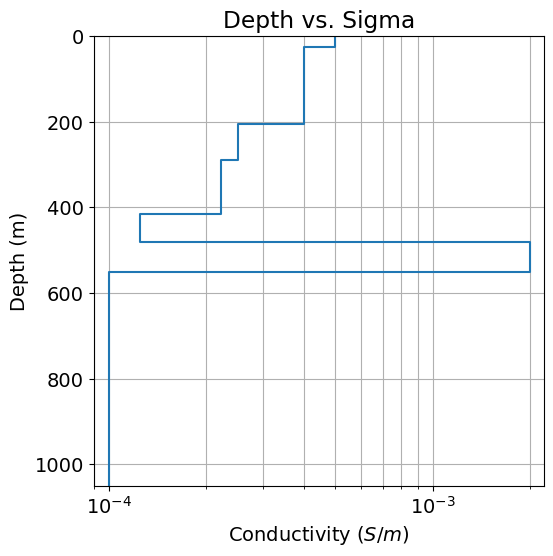

In [2]:
#Geological properties
layer_thicknesses = np.array([25, 180, 85, 125, 65,70,500]) #Thicknesses were obtained from Tuncer, pg. 16
sigma = 1/np.r_[2000.,2500., 4000., 4500.,8000,500,10000]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data
#sigma = 1/np.r_[500.,500., 500., 500.,500,500,500]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data

#Survey Properties
frequencies = np.r_[7.68*10**3, 5.12*10**3, 3.84*10**3, 1.28*10**3,
    9.59*10**2, 6.4*10**2, 4.64*10**2, 3.36*10**2, 2.4*10**2, 1.77*10**2, 1.28*10**2,
    9.699*10**1,8.1*10**1,7.1*10**1,6.1*10**1,5.1*10**1,4.1*10**1,3.275*10**1,2.225*10**1,1.512*10**1,1.025*10**1,
    6.937,4.875]  # frequencies in Hz # Obtained from Cameco Data, Line 304

#Obtaining max and min skin depths given frequencies and expected resisitivies
min_skin_depth = 503*np.sqrt(np.min(1/sigma)/frequencies.max())
max_skin_depth = 503*np.sqrt(np.max(1/sigma)/frequencies.min())



#Plotting 1D Layer Model for visualization
fig = plt.figure(figsize=(10, 5))
ax1 = plot_1d_layer_model(layer_thicknesses, sigma) # figure has base value at log plot
ax1.grid(which="both")
ax1.set_xlabel(r"Conductivity ($S/m$)")
ax1.set_title('Depth vs. Sigma')


In [3]:
#Plotting Skin Depths
print(f'Max Skin Depth: {max_skin_depth}')
print(f'Min Skin Depth: {min_skin_depth}')

Max Skin Depth: 22781.413926989266
Min Skin Depth: 128.34305631457696


### Defining Mesh

Text(0.5, 1.0, 'Tensor Mesh')

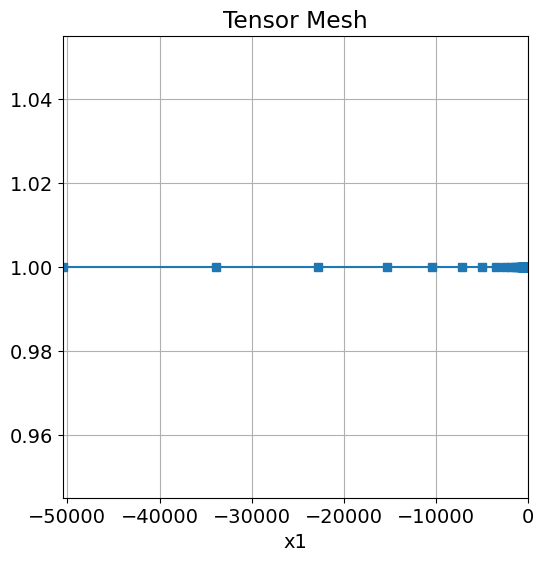

In [4]:
dx = 5  # base cell width x
ncx = 600 * 1/dx  # number of core mesh cells in x
exp_x = 1.5  # expansion rate of padding cells in x
npad_x = int(np.ceil(np.log(1+(max_skin_depth-600) * (exp_x-1)/dx)/np.log(exp_x)))  # number of padding cells in x

# Use a list of tuples to define cell widths in each direction. Each tuple
# contains the cell width, number of cells and the expansion factor. A
# negative sign is used to indicate an interval where cells widths go
# from largest to smallest.
hx = [(dx, npad_x, -exp_x), (dx, ncx)] #, (dx, npad_x, exp_x)]

# We can use flags 'C', '0' and 'N' to shift the xyz position of the mesh
# relative to the origin
mesh = TensorMesh([hx], x0 = "N")

# We can apply the plot_grid method and output to a specified axes object
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
mesh.plot_grid(ax=ax, nodes="True")
ax.set_xbound(mesh.x0[0], mesh.x0[0] + np.sum(mesh.h[0]))
ax.set_title("Tensor Mesh")

In [5]:
#Printing Mesh Values
mesh

TensorMesh: 140 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    140    -50,463.85          0.00      5.00 16,626.28    1.50

In [6]:
mesh.nodes

array([-5.04638510e+04, -3.38375673e+04, -2.27533782e+04, -1.53639188e+04,
       -1.04376125e+04, -7.15340836e+03, -4.96393890e+03, -3.50429260e+03,
       -2.53119507e+03, -1.88246338e+03, -1.44997559e+03, -1.16165039e+03,
       -9.69433594e+02, -8.41289062e+02, -7.55859375e+02, -6.98906250e+02,
       -6.60937500e+02, -6.35625000e+02, -6.18750000e+02, -6.07500000e+02,
       -6.00000000e+02, -5.95000000e+02, -5.90000000e+02, -5.85000000e+02,
       -5.80000000e+02, -5.75000000e+02, -5.70000000e+02, -5.65000000e+02,
       -5.60000000e+02, -5.55000000e+02, -5.50000000e+02, -5.45000000e+02,
       -5.40000000e+02, -5.35000000e+02, -5.30000000e+02, -5.25000000e+02,
       -5.20000000e+02, -5.15000000e+02, -5.10000000e+02, -5.05000000e+02,
       -5.00000000e+02, -4.95000000e+02, -4.90000000e+02, -4.85000000e+02,
       -4.80000000e+02, -4.75000000e+02, -4.70000000e+02, -4.65000000e+02,
       -4.60000000e+02, -4.55000000e+02, -4.50000000e+02, -4.45000000e+02,
       -4.40000000e+02, -

In [7]:
#Defining the sigma backround as the highest conducivity layer (overburden)
sigma_background = 1/4000

#Creating a model (ie. creating an array the same size as the mesh to represent each of the mesh's cells conductivity)
model = np.ones(mesh.n_cells) * sigma_background  # np.zeros(len(x_cells)) 


#Defining Layer Depths
layer_depths = np.array([layer_thicknesses[0],
                         layer_thicknesses[0] + layer_thicknesses[1],
                         layer_thicknesses[0] + layer_thicknesses[1] + layer_thicknesses[2],
                         layer_thicknesses[0] + layer_thicknesses[1] + layer_thicknesses[2] + layer_thicknesses[3],
                         layer_thicknesses[0] + layer_thicknesses[1] + layer_thicknesses[2] + layer_thicknesses[3] + layer_thicknesses[4], 
                         layer_thicknesses[0] + layer_thicknesses[1] + layer_thicknesses[2] + layer_thicknesses[3] + layer_thicknesses[4] + layer_thicknesses[5]])

    
# Defining indexes for layer depths/ depths of separations between layers
layer_1_model = (mesh.cell_centers >= -layer_depths[0])
layer_2_model = (mesh.cell_centers < -layer_depths[0]) & (mesh.cell_centers >= -layer_depths[1])
layer_3_model = (mesh.cell_centers < -layer_depths[1]) & (mesh.cell_centers >= -layer_depths[2])
layer_4_model = (mesh.cell_centers < -layer_depths[2]) & (mesh.cell_centers >= -layer_depths[3])
layer_5_model = (mesh.cell_centers < -layer_depths[3]) & (mesh.cell_centers >= -layer_depths[4])
layer_6_model_ore_body = (mesh.cell_centers < -layer_depths[4]) & (mesh.cell_centers >= -layer_depths[5])
layer_7_model = (mesh.cell_centers < -layer_depths[5])



#Assigning conductivities to each layer per indexes
model[layer_1_model] = sigma[0]
model[layer_2_model] = sigma[1]
model[layer_3_model] = sigma[2]
model[layer_4_model] = sigma[3]
model[layer_5_model] = sigma[4]
model[layer_6_model_ore_body] = sigma[5]
model[layer_7_model] = sigma[6]

print(model)


[0.0001     0.0001     0.0001     0.0001     0.0001     0.0001
 0.0001     0.0001     0.0001     0.0001     0.0001     0.0001
 0.0001     0.0001     0.0001     0.0001     0.0001     0.0001
 0.0001     0.0001     0.0001     0.0001     0.0001     0.0001
 0.0001     0.0001     0.0001     0.0001     0.0001     0.0001
 0.002      0.002      0.002      0.002      0.002      0.002
 0.002      0.002      0.002      0.002      0.002      0.002
 0.002      0.002      0.000125   0.000125   0.000125   0.000125
 0.000125   0.000125   0.000125   0.000125   0.000125   0.000125
 0.000125   0.000125   0.000125   0.00022222 0.00022222 0.00022222
 0.00022222 0.00022222 0.00022222 0.00022222 0.00022222 0.00022222
 0.00022222 0.00022222 0.00022222 0.00022222 0.00022222 0.00022222
 0.00022222 0.00022222 0.00022222 0.00022222 0.00022222 0.00022222
 0.00022222 0.00022222 0.00022222 0.00022222 0.00025    0.00025
 0.00025    0.00025    0.00025    0.00025    0.00025    0.00025
 0.00025    0.00025    0.00025    0

Text(0, 0.5, 'Log_10(sigma)')

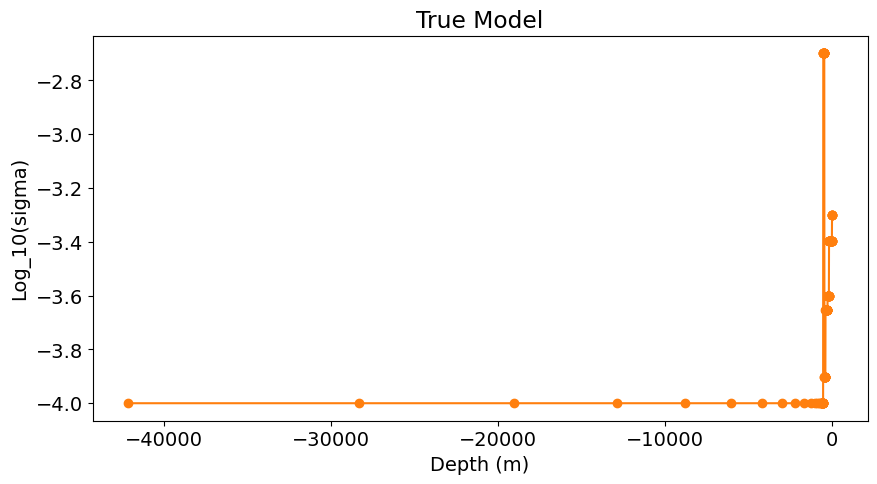

In [8]:
#Plotting Mesh with True Model
fig, ax = plt.subplots(1,1, figsize = (10,5))
mesh.plot_image(np.log10(model), ax = ax)
ax.set_title('True Model')
ax.set_xlabel('Depth (m)')
ax.set_ylabel('Log_10(sigma)')

### Setting up 1D MT Simulation

In [9]:

############
#Creating Sigma map
sigma_map = maps.IdentityMap(nP=mesh.nC)# * wire_map.sigma # Extracting sigma from wire_map

#Setting up RX locations 
rx_loc_single = np.array([[0]])

#Receivers list
receivers_list = [
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="real"),  #Only off diagonal components for 1D
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="imag"),

    nsem.receivers.Impedance(rx_loc_single, orientation="yx", component="real"),
    nsem.receivers.Impedance(rx_loc_single, orientation="yx", component="imag"),
]

source_list = []
for freq in frequencies:
    source_list.append(nsem.sources.Planewave(receivers_list, freq)) # Setting sources as plane waves at each specified frequencies 

survey = nsem.survey.Survey(source_list) #Creating survey object with given sources form source_list

#Creating simulation object
simulation = nsem.Simulation1DElectricField(mesh,
    survey=survey, 
    sigmaMap=sigma_map,
    solver = Mumps)

#Setting true model as previously obtained model
true_model = model

#creating predicted data on basis of true model + receivers, frequencies, orientations, etc.
dpred = simulation.dpred(true_model)
dobs = dpred # Saving for inversion purposes
dpred = dpred.reshape(len(frequencies),4)

Zxy = dpred[:,0]+ 1j* dpred[:,1]
Zyx = dpred[:,2] + 1j*dpred[:,3]

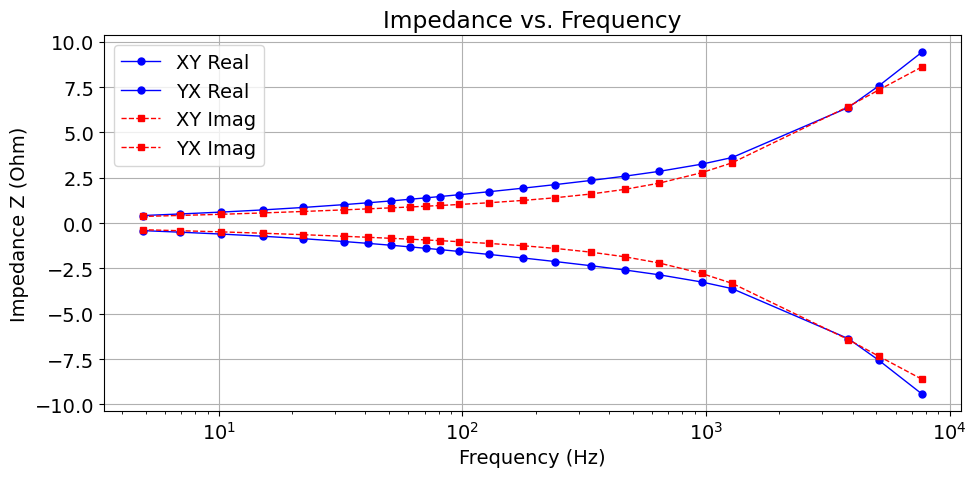

In [10]:
fig, ax = plt.subplots(1,1,figsize=(10, 5))

#Plotting Real Component XY and YX 
ax.semilogx(frequencies, dpred[:,0], "b-o", lw=1, ms=5, label = 'XY Real')
ax.semilogx(frequencies, dpred[:,2], "b-o", lw=1, ms=5, label = 'YX Real')

#Pting Imag Component XY and YX 
ax.semilogx(frequencies, dpred[:,1], "r--s", lw=1, ms=5, label = 'XY Imag')
ax.semilogx(frequencies, dpred[:,3], "r--s", lw=1, ms=5, label = 'YX Imag')

ax.grid()
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Impedance Z (Ohm)")
ax.set_title("Impedance vs. Frequency")
ax.legend

ax.legend()


fig.tight_layout()


In [11]:
#Defining Values to plot apparent resisitivity and phase
omega = 2*np.pi* frequencies

#Computing Apparent resisitvity and phase
apparent_rho = (np.abs(Zxy)**2)/ (scipy.constants.mu_0 * omega)
phase = np.rad2deg(np.arctan2( np.imag(Zxy),np.real(Zxy)))

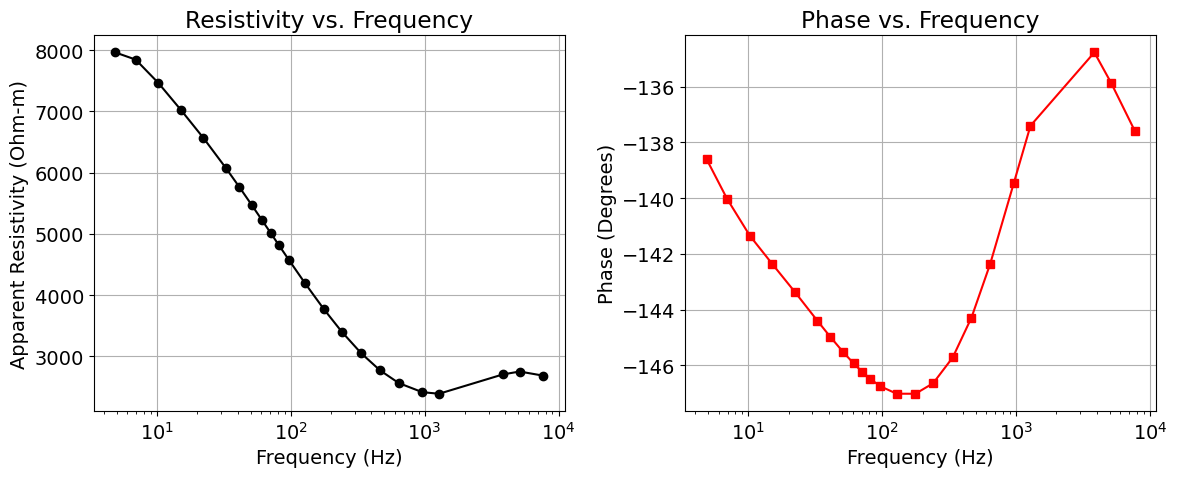

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

#Plotting Apparent Resisitivty
ax[0].semilogx(frequencies, apparent_rho, 'k-o')
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Apparent Resistivity (Ohm-m)")
ax[0].set_title('Resistivity vs. Frequency')
ax[0].grid()

# Plotting Phase
ax[1].semilogx(frequencies, phase, 'r-s')
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Phase (Degrees)")
ax[1].set_title('Phase vs. Frequency')
ax[1].grid()

plt.tight_layout()


# Test Inversion

##### Inversion is still being reviewed...

### Define Inversion Parameters

In [13]:
# dobs = dobs
# standard_deviation = 0.5
# rho_0 = 2000
# rho_ref = 2500
# maxIter=10
# maxIterCG=30
# maxIterLS=30
# alpha_s=1e-10
# alpha_z=1
# beta0_ratio=1
# coolingFactor = 2
# coolingRate=1
# chi_factor=1
# p_s=0
# p_z=0

### Halfspace Inversion

In [14]:
# Defining Mesh for Halfspace
layer_thick_halfspace = [1000]
n_layers_halfspace = 1
rho = 500

# Defining the mapping
conductivity_halfspace_map = maps.ExpMap(nP=n_layers_halfspace)

m0 = np.log(1/500) * np.ones(n_layers_halfspace)

# Reference model, same as starting 
reference_conductivity_model = m0.copy()


### Create Simulation Object

In [15]:
simulation_hsp = nsem.simulation_1d.Simulation1DRecursive(
        survey=survey,
        sigma = 1/rho,
        thicknesses=[],
        sigmaMap=conductivity_halfspace_map
    )

# ### Using this, I get: NotImplementedError: The getJ method hasn't been implemented for the Simulation1DElectricField yet.
# simulation_hsp = nsem.Simulation1DElectricField(mesh,
#     survey=survey, 
#     sigmaMap=conductivity_halfspace_map,
#     solver = Mumps)


### This error is probably being thrown due to the use of update_jacobi in the directives list below

### Setting Up Data for Different Simulaiton Object Above Compared to Forward Model

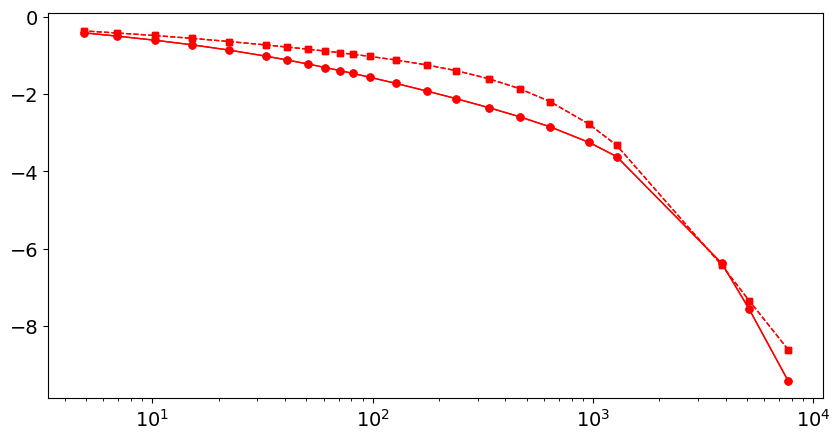

In [16]:
dobs_new = [dpred[:,0] , dpred[:,1], dpred[:,2]*-1 ,  dpred[:,3] * -1 ] # Putting the xy and yx components into a list
dobs_new = np.array(dobs_new) # turning it to a numpy array
dobs_new = dobs_new.flatten(order = 'F') #Flattening it per column instead of per row


real_data_new = dobs_new.reshape(len(frequencies),4) # Reshaping to 23 rows and 4 columns

fig, ax = plt.subplots(1,1,figsize=(10, 5))

#Plotting Real Component XY and YX 
ax.semilogx(frequencies, real_data_new[:,0], "r-o", lw=1, ms=5, label = 'XY Real- Real')
ax.semilogx(frequencies, real_data_new[:,2], "r-o", lw=1, ms=5, label = 'YX Real - Real')

#Pting Imag Component XY and YX 
ax.semilogx(frequencies, real_data_new[:,1], "r--s", lw=1, ms=5, label = 'XY Imag - Real')
ax.semilogx(frequencies, real_data_new[:,3], "r--s", lw=1, ms=5, label = 'YX Imag - Real')

plt.show()

### Data Misfit

In [17]:
#uncertainties = 0.05 * np.abs(dobs) * np.ones(np.shape(dobs))
data_object = data.Data(survey,
                        dobs=dobs_new,
                        relative_error=0.05) # Using relative error instead of uncertainty
dmis_hsp_L2 = data_misfit.L2DataMisfit(simulation=simulation_hsp,
                                       data=data_object)

### Regularization

In [18]:

h = np.r_[layer_thick_halfspace]

# Create regularization mesh
regularization_mesh_hs = TensorMesh([h], "N")

reg_L2 = regularization.WeightedLeastSquares(
        regularization_mesh_hs,
        length_scale_x=10.0,
        reference_model=reference_conductivity_model,
        reference_model_in_smooth=True
        )

#Set regularization parameters:
reg_L2.alpha_s = 1
reg_L2.alpha_x= 5



### Optimization

In [19]:
opt_L2 = optimization.InexactGaussNewton(
    maxIter=50, maxIterLS=20, maxIterCG=20, tolCG=1e-3
)

### Inversion Parameters

In [20]:
inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_hsp_L2, reg_L2, opt_L2)

#Set inversion directives:
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=5)
beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.0)
save_L2_hp = directives.SaveOutputDictEveryIteration()

directives_list_L2 = [
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_L2_hp
]

### Halfspace Inversion!

In [21]:
# Combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run the inversion
recovered_halfspace_model_L2 = inv_L2.run(m0)

## Get the recovered halfspace resistivity from model estimated
conductivities_hsp = conductivity_halfspace_map * recovered_halfspace_model_L2

INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  6.38e+00  1.53e+04  0.00e+00  1.53e+04                                 
   1  6.38e+00  1.07e+04  2.87e+02  1.26e+04    8.20e+03      0              
   2  6.38e+00  9.80e+03  4.14e+02  1.24e+04    1.84e+03      0              
   3  6.38e+00  9.59e+03  4.47e+02  1.24e+04    4.39e+02      0              
   4  2.55e+00  5.36e+03  1.41e+03  8.95e+03    5.22e+03      0              
   5  2.55e+00  4.66e+03  1.65e+03  8.87e+03    1.32e+03      0              
   6  2.55e+00  4.51e+03  1.70e+03  8.86e+03    3.07e+02      0              
   7  1.02e+00  2.61e+03  2.76e+03  5.42e+03    4.07e+03      0              
   8  1.02e+00  2.54e+03  2.82e+03  5.42e+03    2.82e+02      0              
   9  1.02e+00  2.54e+03

### Results!

In [22]:
print("Conductivity halfspace: ", conductivities_hsp)
print("Resistivity halfspace: ", 1/conductivities_hsp)
rho_hsp_pred = 1/conductivities_hsp

Conductivity halfspace:  [0.00030498]
Resistivity halfspace:  [3278.89163418]


### Moving to a Multi-Layered Inversion using the recovered halfspace results as m0

In [23]:
# Defining Mesh for 7 layers
layer_thick = np.array([25, 180, 85, 125, 65, 70])   #m
rho = np.r_[2000., 2500., 4000., 4500., 8000., 500., 10000.] #ohm-m
n_layers_halfspace = len(rho)


# Defining the mapping
conductivity_halfspace_map = maps.ExpMap(nP=n_layers_halfspace)

m0 = np.log(1/rho_hsp_pred)* np.ones(n_layers_halfspace)

# Reference model, same as starting 
reference_conductivity_model = m0.copy()


simulation_hsp = nsem.simulation_1d.Simulation1DRecursive(
        survey=survey,
        sigma = 1/rho,
        thicknesses=layer_thick,
        sigmaMap=conductivity_halfspace_map
    )

dobs_new = [dpred[:,0] , dpred[:,1], dpred[:,2]*-1 ,  dpred[:,3] * -1 ] # Putting the xy and yx components into a list
dobs_new = np.array(dobs_new) # turning it to a numpy array
dobs_new = dobs_new.flatten(order = 'F') #Flattening it per column instead of per row



### Data Misfit
data_object = data.Data(survey,
                        dobs=dobs_new,
                        relative_error=0.05) # Using relative error instead of uncertainty
dmis_hsp_L2 = data_misfit.L2DataMisfit(simulation=simulation_hsp,
                                       data=data_object)

### Regularization

h = np.r_[layer_thick]

# Create regularization mesh
regularization_mesh_hs = TensorMesh([np.ones(n_layers_halfspace)], "N")

reg_L2 = regularization.WeightedLeastSquares(
        regularization_mesh_hs,
        length_scale_x=10.0,
        reference_model=reference_conductivity_model,
        reference_model_in_smooth=True
        )

#Set regularization parameters:
reg_L2.alpha_s = 1
reg_L2.alpha_x= 5


### Optimization
opt_L2 = optimization.InexactGaussNewton(
    maxIter=50, maxIterLS=20, maxIterCG=20, tolCG=1e-3
)

### Inversion Parameters

inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_hsp_L2, reg_L2, opt_L2)

#Set inversion directives:
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=5)
beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.0)
save_L2_hp = directives.SaveOutputDictEveryIteration()

directives_list_L2 = [
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_L2_hp
]

### Inversion !!!
# Combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run the inversion
recovered_halfspace_model_L2 = inv_L2.run(m0)

## Get the recovered halfspace resistivity from model estimated
conductivities_ml = conductivity_halfspace_map * recovered_halfspace_model_L2




INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  5.63e+02  2.12e+03  0.00e+00  2.12e+03                                 
   1  5.63e+02  9.57e+02  6.50e-01  1.32e+03    3.21e+03      0              
   2  5.63e+02  8.65e+02  7.92e-01  1.31e+03    4.03e+02      0              
   3  5.63e+02  8.54e+02  8.11e-01  1.31e+03    4.65e+01      0              
   4  2.25e+02  5.01e+02  1.75e+00  8.94e+02    1.13e+03      0              
   5  2.25e+02  4.67e+02  1.89e+00  8.91e+02    1.71e+02      0              
   6  2.25e+02  4.62e+02  1.90e+00  8.91e+02    2.06e+01      0              
   7  9.01e+01  2.65e+02  3.20e+00  5.53e+02    7.21e+02      0              
   8  9.01e+01  2.46e+02  3.39e+00  5.52e+02    1.17e+02      0              
   9  9.01e+01  2.44e+02

In [24]:
np.round(1/conductivities_ml[::-1]), 1/sigma

(array([2572., 2681., 2466., 2014., 1861., 3760., 8460.]),
 array([ 2000.,  2500.,  4000.,  4500.,  8000.,   500., 10000.]))

Text(0.5, 1.0, 'Depth vs. Sigma')

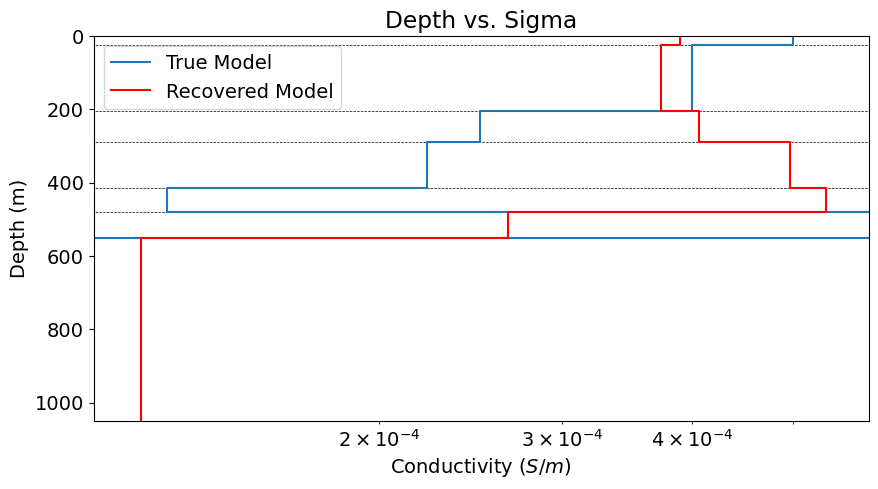

In [25]:
#Plotting True Vs recovered
fig , ax= plt.subplots(1,1,figsize=(10, 5))
plot_1d_layer_model(layer_thicknesses, sigma, label = 'True Model',ax = ax, show_layers=True) # figure has base value at log plot
plot_1d_layer_model(layer_thicknesses, conductivities_ml[::-1],c = 'r', label = 'Recovered Model', ax = ax)
#ax.grid(which="both")
ax.legend()
ax.set_xlabel(r"Conductivity ($S/m$)")
ax.set_title('Depth vs. Sigma')

### Layered Inversion

In [26]:
#Defining inversion function
dobs = dobs
standard_deviation = 0.5
rho_0 = 2000
rho_ref = 2500
maxIter=10
maxIterCG=30
maxIterLS=30
alpha_s=1e-10
alpha_z=1
beta0_ratio=1
coolingFactor = 2
coolingRate=1
chi_factor=1
p_s=0
p_z=0

layer_thicknesses_inv = layer_thicknesses[:6] # Layers without halfspace

n_layer = len(layer_thicknesses_inv) + 1 # Total Number of Layers + halfspace

mesh_inv = TensorMesh([(np.r_[layer_thicknesses_inv, layer_thicknesses_inv[-1]])], "N")

sigma_map = maps.ExpMap(nP = n_layer)
    
simulation = nsem.simulation_1d.Simulation1DRecursive(
    survey=survey, 
    sigmaMap=sigma_map,
    thicknesses=layer_thicknesses_inv,
)
# Define the data 
data_object = data.Data(survey, dobs=dobs, standard_deviation=standard_deviation)    

# Initial model
m0 = np.ones(n_layer) * np.log(1./rho_0)

# Reference model
mref = np.ones(n_layer) * np.log(1./rho_ref)    

dmis = data_misfit.L2DataMisfit(simulation=simulation, data=data_object)

# Define the regularization (model objective function)
reg = regularization.Sparse(
    mesh_inv, alpha_s=alpha_s, alpha_x=alpha_z, 
    reference_model=mref,
    reference_model_in_smooth=False,
    mapping=maps.IdentityMap(nP = n_layer),
)

# Define how the optimization problem is solved. Here we will use an inexact
# Gauss-Newton approach that employs the conjugate gradient solver.
opt = optimization.InexactGaussNewton(
maxIter=maxIter,
maxIterCG=maxIterCG,
maxIterLS=maxIterLS,
)


# Define the inverse problem
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)

#######################################################################
# Define Inversion Directives
# ---------------------------
#
# Here we define any directives that are carried out during the inversion. This
# includes the cooling schedule for the trade-off parameter (beta), stopping
# criteria for the inversion and saving inversion results at each iteration.
#

# Defining a starting value for the trade-off parameter (beta) between the data
# misfit and the regularization.
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=beta0_ratio)

# Set the rate of reduction in trade-off parameter (beta) each time the
# the inverse problem is solved. And set the number of Gauss-Newton iterations
# for each trade-off paramter value.
beta_schedule = directives.BetaSchedule(coolingFactor=coolingFactor, coolingRate=coolingRate)
save_dictionary = directives.SaveOutputDictEveryIteration()
save_dictionary.outDict = {}
# Setting a stopping criteria for the inversion.
target_misfit = directives.TargetMisfit(chifact=chi_factor)
precond = directives.UpdatePreconditioner()

# The directives are defined as a list.
directives_list = [
    precond,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_dictionary
]

#####################################################################
# Running the Inversion
# ---------------------
#
# To define the inversion object, we need to define the inversion problem and
# the set of directives. We can then run the inversion.
#

# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

# Run the inversion
recovered_model = inv.run(m0)    
output_dict= save_dictionary.outDict
#return recovered_model, 

INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  4.80e+03  6.43e+03  3.09e-09  6.43e+03                                 
   1  4.80e+03  4.16e+03  4.66e-03  4.18e+03    1.45e+03      0              
   2  2.40e+03  3.79e+03  9.72e-03  3.81e+03    3.48e+02      0              
   3  1.20e+03  3.74e+03  4.44e-05  3.74e+03    6.32e+01      0              
   4  6.00e+02  3.73e+03  3.94e-06  3.73e+03    7.95e+00      0              
   5  3.00e+02  3.73e+03  6.16e-06  3.73e+03    1.17e+00      0              
   6  1.50e+02  3.73e+03  8.88e-06  3.73e+03    1.58e-01      0              
   7  7.50e+01  3.73e+03  1.21e-05  3.73e+03    2.13e-02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 1.8727e-02 <= tolF*(1+|f0|) 

In [27]:
target_misfit = dpred.size
iterations = list(output_dict.keys())
n_iteration = len(iterations)
phi_ds = np.zeros(n_iteration)
phi_ms = np.zeros(n_iteration)
betas = np.zeros(n_iteration)
for ii, iteration in enumerate(iterations):
    phi_ds[ii] = output_dict[iteration]['phi_d']
    phi_ms[ii] = output_dict[iteration]['phi_m']
    betas[ii] = output_dict[iteration]['beta']

In [28]:
matplotlib.rcParams['font.size'] = 14
def tikhonov_curve(iteration, scale='log'):
    fig, ax = plt.subplots(1,1, figsize=(5,5))
    ax.plot(phi_ms, phi_ds)
    ax.plot(phi_ms[iteration-1], phi_ds[iteration-1], 'ro')
    ax.set_xlabel(r"$\phi_m$")
    ax.set_ylabel(r"$\phi_d$")
    if scale == 'log':
        ax.set_xscale('log')
        ax.set_yscale('log')
    xlim = ax.get_xlim()
    ax.plot(xlim, np.ones(2) * target_misfit, '--')
    ax.set_title("Iteration={:d}, Beta = {:.1e}".format(iteration, betas[iteration-1]))
    ax.set_xlim(xlim)
    plt.show()

In [29]:
from ipywidgets import interact, widgets
Q_iter = interact(
    tikhonov_curve, 
    iteration=widgets.IntSlider(min=1, max=int(n_iteration), value=n_iteration),
    scale=widgets.RadioButtons(options=['linear', 'log'])
)

interactive(children=(IntSlider(value=7, description='iteration', max=7, min=1), RadioButtons(description='sca…

In [30]:
# #Plotting
# iteration = 5
# dpred = output_dict[iteration]['dpred']
# m = output_dict[iteration]['m']
# fig = plt.figure(figsize=(16, 5))
# gs = gridspec.GridSpec(1, 5, figure=fig)

# ax0 = fig.add_subplot(gs[0, 0])
# plot_1d_layer_model(layer_thicknesses, 1/sigma) # figure has base value at log plot
# plot_1d_layer_model(
#     layer_thicknesses_inv,
#     1.0 / np.exp(m),
#     ax=ax0,
#     color="k",
#     label=r"$m_{Inv}$",
#     linestyle="--",
# )
# ax0.legend()
# ax0.set_xlabel(r"Resistivity [$\Omega$m]")
# ax0.set_title('Model from iteration ' + str(iteration), fontsize=14)
# ax0.grid(True, which='both', alpha=0.5)


# ax = fig.add_subplot(gs[0, 2:])
# ax.loglog(1./frequencies, dpred.reshape((len(frequencies), 2))[:,0], color='C0', label=r'$d_{pred}$ ($\rho_{a}$)')

# ax_1 = ax.twinx()
# ax_1.plot(1./frequencies, dpred.reshape((len(frequencies), 2))[:,1], color='C1', label=r'$d_{pred}$ ($\Phi$)')
# ax.set_xlabel("Period [s]")
# ax.grid(True, which='both', alpha=0.5)
# ax.set_ylabel(r"Apparent resistivity [$\Omega$m]")
# ax_1.set_ylabel(r"Phase [$\degree$]")
# # ax.legend(bbox_to_anchor=(1.1,1))
# ax.legend(loc=2)
# ax_1.legend(loc=1)
# plt.show()